In [1]:
# Importar las librerías necesarias
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('calendar.csv')

In [3]:
df

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,50778,2020-04-26,f,"$2,655.00","$2,655.00",5.0,1125.0
1,133654,2020-04-27,t,"$1,150.00","$1,150.00",4.0,1125.0
2,133654,2020-04-28,t,"$1,150.00","$1,150.00",4.0,1125.0
3,133654,2020-04-29,t,"$1,150.00","$1,150.00",4.0,1125.0
4,133654,2020-04-30,t,"$1,150.00","$1,150.00",4.0,1125.0
...,...,...,...,...,...,...,...
8661281,43178560,2021-04-21,f,"$3,319.00","$3,319.00",1.0,1125.0
8661282,43178560,2021-04-22,f,"$3,319.00","$3,319.00",1.0,1125.0
8661283,43178560,2021-04-23,f,"$3,319.00","$3,319.00",1.0,1125.0
8661284,43178560,2021-04-24,f,"$3,319.00","$3,319.00",1.0,1125.0


In [4]:
df.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,50778,2020-04-26,f,"$2,655.00","$2,655.00",5.0,1125.0
1,133654,2020-04-27,t,"$1,150.00","$1,150.00",4.0,1125.0
2,133654,2020-04-28,t,"$1,150.00","$1,150.00",4.0,1125.0
3,133654,2020-04-29,t,"$1,150.00","$1,150.00",4.0,1125.0
4,133654,2020-04-30,t,"$1,150.00","$1,150.00",4.0,1125.0


In [5]:
df.tail()


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
8661281,43178560,2021-04-21,f,"$3,319.00","$3,319.00",1.0,1125.0
8661282,43178560,2021-04-22,f,"$3,319.00","$3,319.00",1.0,1125.0
8661283,43178560,2021-04-23,f,"$3,319.00","$3,319.00",1.0,1125.0
8661284,43178560,2021-04-24,f,"$3,319.00","$3,319.00",1.0,1125.0
8661285,43178560,2021-04-25,f,"$3,319.00","$3,319.00",1.0,1125.0


In [6]:
df.dtypes

listing_id          int64
date               object
available          object
price              object
adjusted_price     object
minimum_nights    float64
maximum_nights    float64
dtype: object

In [7]:
print("Descripción estadística")
print(df.describe())

Descripción estadística
         listing_id  minimum_nights  maximum_nights
count  8.661286e+06    8.661181e+06    8.661181e+06
mean   2.668546e+07    6.043400e+00    7.685193e+02
std    1.263363e+07    2.551562e+01    8.653444e+02
min    1.150800e+04    1.000000e+00    1.000000e+00
25%    1.765680e+07    1.000000e+00    9.000000e+01
50%    3.000878e+07    3.000000e+00    1.125000e+03
75%    3.736241e+07    4.000000e+00    1.125000e+03
max    4.328606e+07    1.125000e+03    9.999900e+04


In [8]:
print("Informacion estadística:")
print(df.info())

Informacion estadística:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661286 entries, 0 to 8661285
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 462.6+ MB
None


In [9]:
print(df.isnull().sum())

listing_id          0
date                0
available           0
price               0
adjusted_price      0
minimum_nights    105
maximum_nights    105
dtype: int64


In [10]:
cl2 = df.copy()

In [11]:
cl2 = cl2.dropna(subset=['minimum_nights', 'maximum_nights'])

print(cl2[['minimum_nights', 'maximum_nights']].isnull().sum())

minimum_nights    0
maximum_nights    0
dtype: int64


In [12]:
cl2 = cl2.drop_duplicates()
cl2


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,50778,2020-04-26,f,"$2,655.00","$2,655.00",5.0,1125.0
1,133654,2020-04-27,t,"$1,150.00","$1,150.00",4.0,1125.0
2,133654,2020-04-28,t,"$1,150.00","$1,150.00",4.0,1125.0
3,133654,2020-04-29,t,"$1,150.00","$1,150.00",4.0,1125.0
4,133654,2020-04-30,t,"$1,150.00","$1,150.00",4.0,1125.0
...,...,...,...,...,...,...,...
8661281,43178560,2021-04-21,f,"$3,319.00","$3,319.00",1.0,1125.0
8661282,43178560,2021-04-22,f,"$3,319.00","$3,319.00",1.0,1125.0
8661283,43178560,2021-04-23,f,"$3,319.00","$3,319.00",1.0,1125.0
8661284,43178560,2021-04-24,f,"$3,319.00","$3,319.00",1.0,1125.0


In [13]:
# Convertir 'minimum_nights' y 'maximum_nights' a enteros
cl2['minimum_nights'] = cl2['minimum_nights'].astype(int)
cl2['maximum_nights'] = cl2['maximum_nights'].astype(int)

# Verificar el cambio
print(cl2[['minimum_nights', 'maximum_nights']].head())

   minimum_nights  maximum_nights
0               5            1125
1               4            1125
2               4            1125
3               4            1125
4               4            1125


In [14]:
cl2


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,50778,2020-04-26,f,"$2,655.00","$2,655.00",5,1125
1,133654,2020-04-27,t,"$1,150.00","$1,150.00",4,1125
2,133654,2020-04-28,t,"$1,150.00","$1,150.00",4,1125
3,133654,2020-04-29,t,"$1,150.00","$1,150.00",4,1125
4,133654,2020-04-30,t,"$1,150.00","$1,150.00",4,1125
...,...,...,...,...,...,...,...
8661281,43178560,2021-04-21,f,"$3,319.00","$3,319.00",1,1125
8661282,43178560,2021-04-22,f,"$3,319.00","$3,319.00",1,1125
8661283,43178560,2021-04-23,f,"$3,319.00","$3,319.00",1,1125
8661284,43178560,2021-04-24,f,"$3,319.00","$3,319.00",1,1125


In [15]:
# Define los rangos para agrupación
bins_min = [0, 3, 7, 14, 30, 60, 365]
labels_min = ['0-3', '4-7', '8-14', '15-30', '31-60', '61+']

# Amplía el rango en bins_max para incluir 1125
bins_max = [0, 7, 14, 30, 60, 180, 365, 1126]  # Extiende el rango hasta 1126
labels_max = ['0-7', '8-14', '15-30', '31-60', '61-180', '181-365', '366+']  # Agrega rango adicional

# Crear categorías agrupadas
cl2['min_nights_range'] = pd.cut(cl2['minimum_nights'], bins=bins_min, labels=labels_min, right=False)
cl2['max_nights_range'] = pd.cut(cl2['maximum_nights'], bins=bins_max, labels=labels_max, right=False)

# Contar frecuencia en cada rango
min_counts = cl2['min_nights_range'].value_counts()
max_counts = cl2['max_nights_range'].value_counts()

# Verificar las cuentas
print(min_counts)
print(max_counts)

min_nights_range
0-3      4214204
4-7      3017826
8-14      742057
15-30     365212
31-60     212965
61+       100161
Name: count, dtype: int64
max_nights_range
366+       5892913
61-180      747247
31-60       702324
15-30       458583
181-365     416956
8-14        276847
0-7         159011
Name: count, dtype: int64


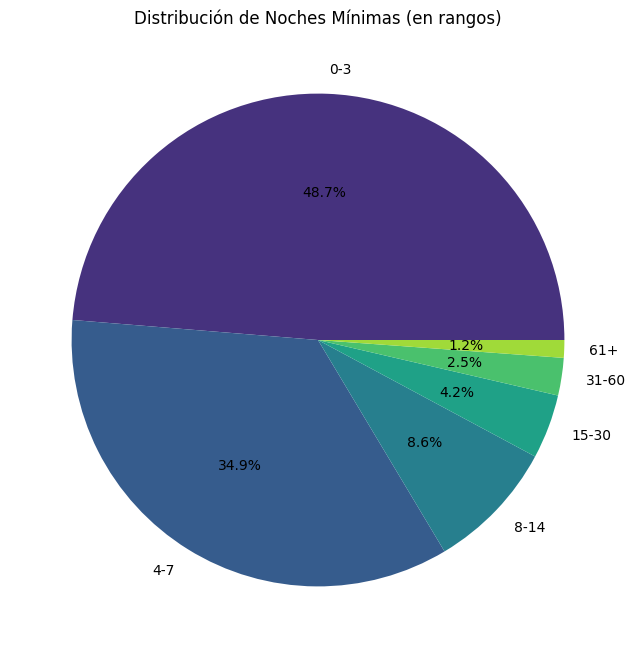

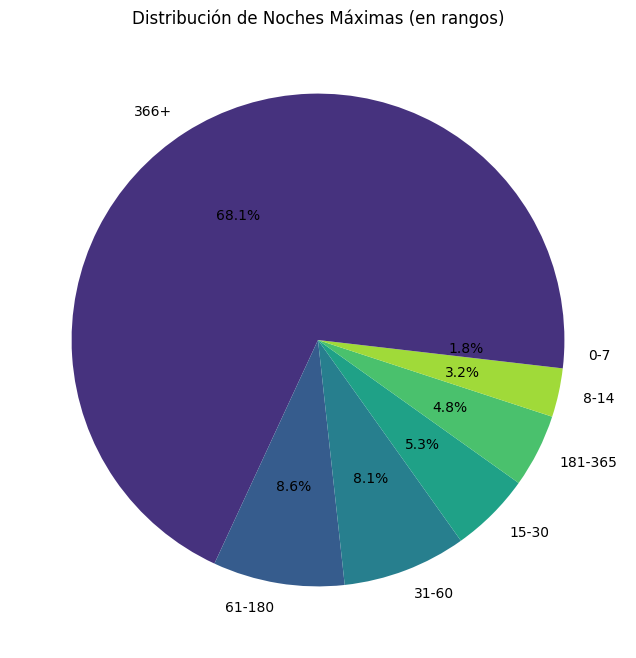

In [16]:
plt.figure(figsize=(8, 8))
plt.pie(min_counts, labels=min_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Distribución de Noches Mínimas (en rangos)')
plt.show()

# Pie chart para 'maximum_nights'
plt.figure(figsize=(8, 8))
plt.pie(max_counts, labels=max_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Distribución de Noches Máximas (en rangos)')
plt.show()

In [17]:
cl2['date'] = pd.to_datetime(cl2['date'])

In [18]:
print(cl2['date'].min(), cl2['date'].max())
print(cl2['available'].value_counts())

2020-04-26 00:00:00 2021-04-26 00:00:00
available
t    5031187
f    3629994
Name: count, dtype: int64


In [19]:
cl2.to_csv('datos_limpios_cl.csv', index=False)